# Codveda Data Analytics Internship - Level 2

I did two of the three tasks for this level: **Task 2 (time series analysis)** and **Task 3 (K-Means clustering)**. Both use the same file, daily prices for 505 large US companies from 2014 to 2017.

The file was cleaned first with `src/01_clean_data.py` (14 rows removed: 11 with a missing price and 3 with impossible prices). This notebook starts from the cleaned version.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid")
DATA_FILE = Path("data") / "stock_prices_clean.csv"

In [2]:
df = pd.read_csv(DATA_FILE, parse_dates=["date"])

print(f"{len(df):,} rows, {df['symbol'].nunique()} stocks")
print("from", df["date"].min().date(), "to", df["date"].max().date())
print("missing values:", int(df.isna().sum().sum()))
df.head()

497,458 rows, 505 stocks
from 2014-01-02 to 2017-12-29
missing values: 0


,symbol,date,open,high,low,close,volume
0,A,2014-01-02,57.10,57.100,56.15,56.21,1916160
1,A,2014-01-03,56.39,57.345,56.26,56.92,1866651
2,A,2014-01-06,57.40,57.700,56.56,56.64,1777472
3,A,2014-01-07,56.95,57.630,56.93,57.45,1463208
4,A,2014-01-08,57.33,58.540,57.17,58.39,2659468


---
## Task 2 - Time series analysis

I picked AAPL. It has all 1,007 trading days without any gap, and it is easy to compare the results with what happened to the company.

AAPL - 1007 trading days


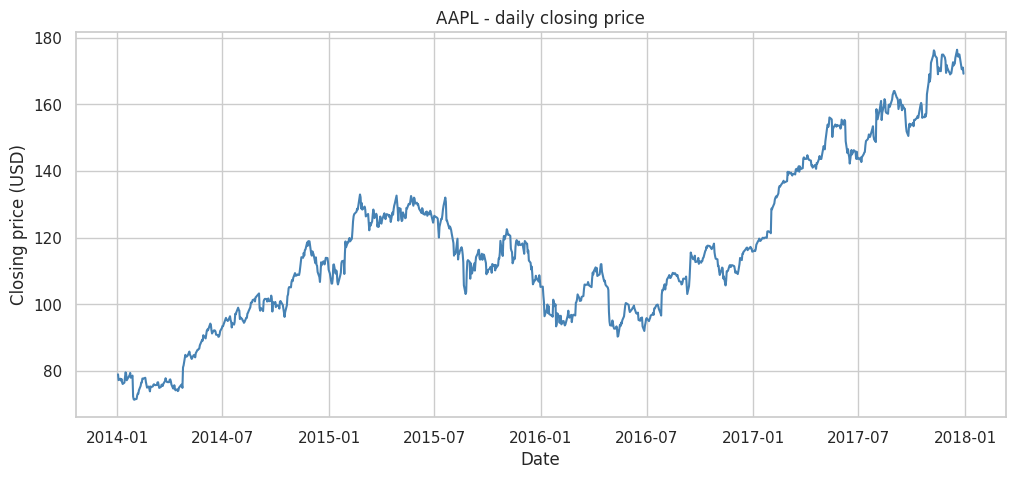

,first,last,min,max,change_pct
date,,,,,
2014,79.0,110.4,71.4,119.0,39.7
2015,109.3,105.3,103.1,133.0,-3.7
2016,105.4,115.8,90.3,118.2,9.9
2017,116.2,169.2,116.0,176.4,45.7


In [3]:
SYMBOL = "AAPL"
close = df.loc[df["symbol"] == SYMBOL].set_index("date")["close"].sort_index()
print(SYMBOL, "-", len(close), "trading days")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(close.index, close.values, color="steelblue")
ax.set_title(f"{SYMBOL} - daily closing price")
ax.set_xlabel("Date")
ax.set_ylabel("Closing price (USD)")
plt.show()

by_year = close.groupby(close.index.year).agg(["first", "last", "min", "max"])
by_year["change_pct"] = (by_year["last"] / by_year["first"] - 1) * 100
by_year.round(1)

The price rises in 2014 (+39.7%), is flat to down in 2015 (-3.7%), slowly recovers in 2016 (+9.9%) and climbs a lot in 2017 (+45.7%, ending around 169 USD). The top of 2015 is 133 USD and the bottom of 2016 is 90 USD. So there is a clear trend (up, down, up) with a lot of day-to-day noise on top of it.

### Decomposition: trend, seasonality, residuals

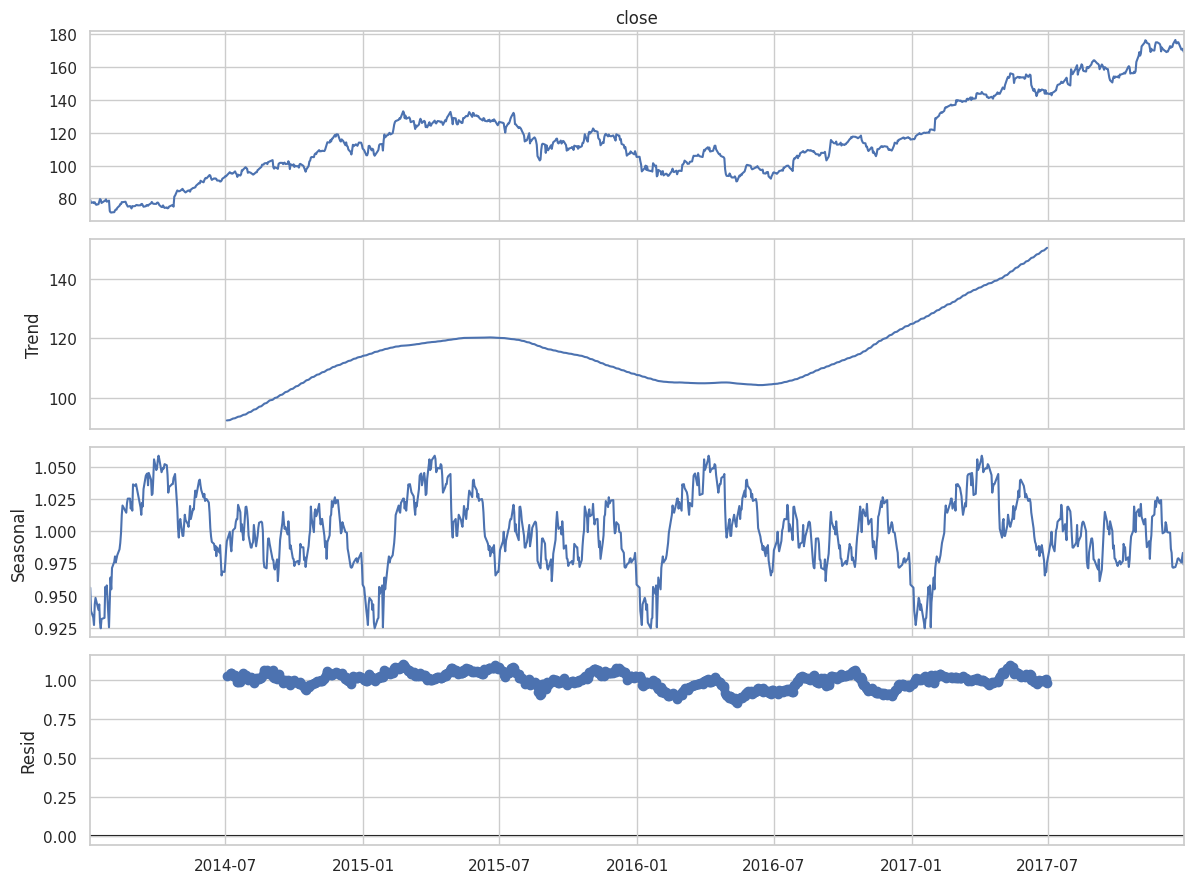

seasonal factor goes from 0.925 to 1.058
residual std = 0.047


In [4]:
# multiplicative because the moves get bigger when the price is higher
# period = 252 trading days, about one year
parts = seasonal_decompose(close, model="multiplicative", period=252)

fig = parts.plot()
fig.set_size_inches(12, 9)
plt.tight_layout()
plt.show()

print(f"seasonal factor goes from {parts.seasonal.min():.3f} to {parts.seasonal.max():.3f}")
print(f"residual std = {parts.resid.std():.3f}")

The trend has the same up, down, up shape as the raw price. It does not cover the first and last months because a centred 252-day average can't be computed at the edges.

The seasonal factor moves between 0.925 and 1.058, high in the first months of the year and low around December. The residuals have a standard deviation of 0.047 (roughly 5%).

To check the seasonal part another way, I averaged the return of each calendar month.

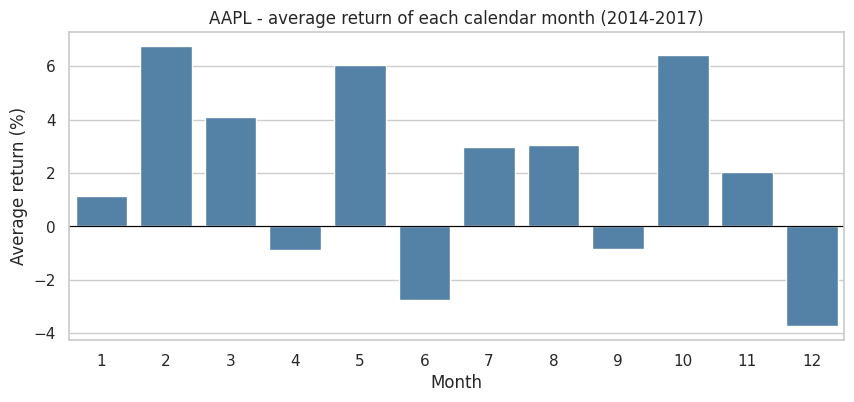

In [5]:
month_end = close.resample("ME").last()
monthly_return = month_end.pct_change().dropna() * 100
avg_by_month = monthly_return.groupby(monthly_return.index.month).mean()

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(x=avg_by_month.index, y=avg_by_month.values, color="steelblue", ax=ax)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title(f"{SYMBOL} - average return of each calendar month (2014-2017)")
ax.set_xlabel("Month")
ax.set_ylabel("Average return (%)")
plt.show()

February (+6.7%), October (+6.4%) and May (+6.1%) are the best months, December (-3.7%) and June (-2.7%) the worst. It fits the decomposition more or less, but each bar is the average of only four values (one per year). I would not call it proven seasonality, it is a hint at best.

### Moving averages

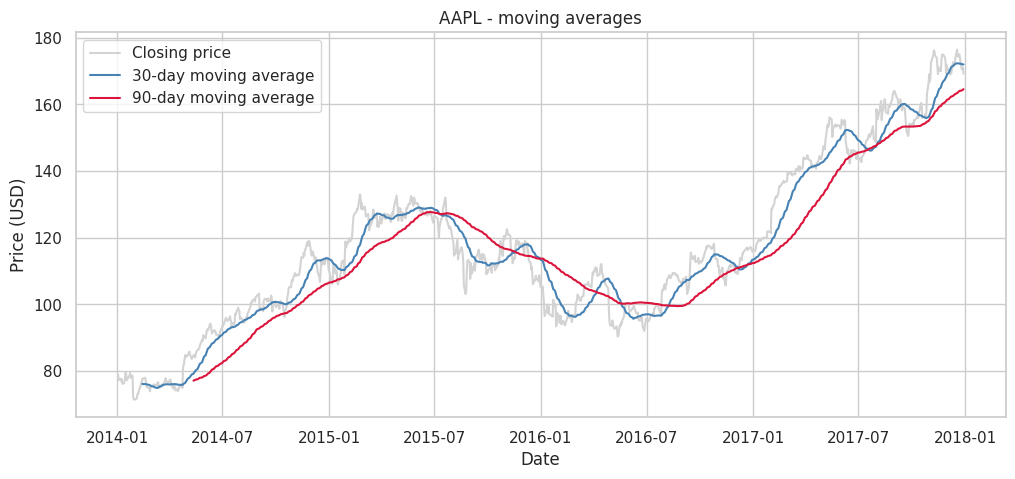

In [6]:
ma_30 = close.rolling(30).mean()
ma_90 = close.rolling(90).mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(close.index, close.values, color="lightgray", label="Closing price")
ax.plot(ma_30.index, ma_30.values, color="steelblue", label="30-day moving average")
ax.plot(ma_90.index, ma_90.values, color="crimson", label="90-day moving average")
ax.set_title(f"{SYMBOL} - moving averages")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend()
plt.show()

The 30-day line follows the price closely. The 90-day line is smoother but reacts later, which is visible at the 2015 peak and the 2016 bottom. The price is mostly above both lines during the 2014 and 2017 rises and goes under them during the fall of 2015-2016.

In [7]:
# extra: is the series stationary?
def adf(series, label):
    stat, p_value = adfuller(series.dropna())[:2]
    verdict = "stationary" if p_value < 0.05 else "not stationary"
    print(f"{label:<14} ADF = {stat:7.2f}   p = {p_value:.4f}   -> {verdict}")

adf(close, "closing price")
adf(close.pct_change(), "daily returns")

closing price  ADF =   -0.54   p = 0.8839   -> not stationary
daily returns  ADF =  -31.04   p = 0.0000   -> stationary


The closing price is not stationary (p = 0.88) but the daily returns are (p < 0.001). This is the usual reason why people model returns and not prices.

---
## Task 3 - Clustering with K-Means

Here each stock is one point. I describe every stock over the four years with four numbers: average daily return, volatility (standard deviation of the daily return), average daily volume and average closing price. I use the log10 of volume and price because both have a few very large values. Stocks with less than 250 days of data are left out.

In [8]:
df = df.sort_values(["symbol", "date"])
df["daily_return"] = df.groupby("symbol")["close"].pct_change()

stocks = df.groupby("symbol").agg(
    avg_daily_return=("daily_return", "mean"),
    volatility=("daily_return", "std"),
    avg_volume=("volume", "mean"),
    avg_price=("close", "mean"),
    n_days=("close", "size"),
)
stocks = stocks[stocks["n_days"] >= 250].copy()
stocks["log_volume"] = np.log10(stocks["avg_volume"])
stocks["log_price"] = np.log10(stocks["avg_price"])

FEATURES = ["avg_daily_return", "volatility", "log_volume", "log_price"]
print(len(stocks), "stocks kept")
stocks[FEATURES].describe().round(4)

500 stocks kept


,avg_daily_return,volatility,log_volume,log_price
count,500.0000,500.0000,500.0000,500.0000
mean,0.0005,0.0155,6.4027,1.8186
std,0.0005,0.0049,0.4073,0.2958
min,-0.0023,0.0083,5.2353,0.7715
25%,0.0002,0.0122,6.1242,1.6411
50%,0.0005,0.0144,6.3591,1.8207
75%,0.0007,0.0176,6.6343,1.9962
max,0.0028,0.0455,7.9512,3.1431


### Standardizing

The features are on very different scales (volatility is around 0.015, log volume around 6). Without scaling, K-Means would almost ignore volatility, so I standardize everything first.

In [9]:
X = StandardScaler().fit_transform(stocks[FEATURES])
print("means:", X.mean(axis=0).round(3))
print("stds :", X.std(axis=0).round(3))

means: [ 0. -0.  0.  0.]
stds : [1. 1. 1. 1.]


### Choosing k

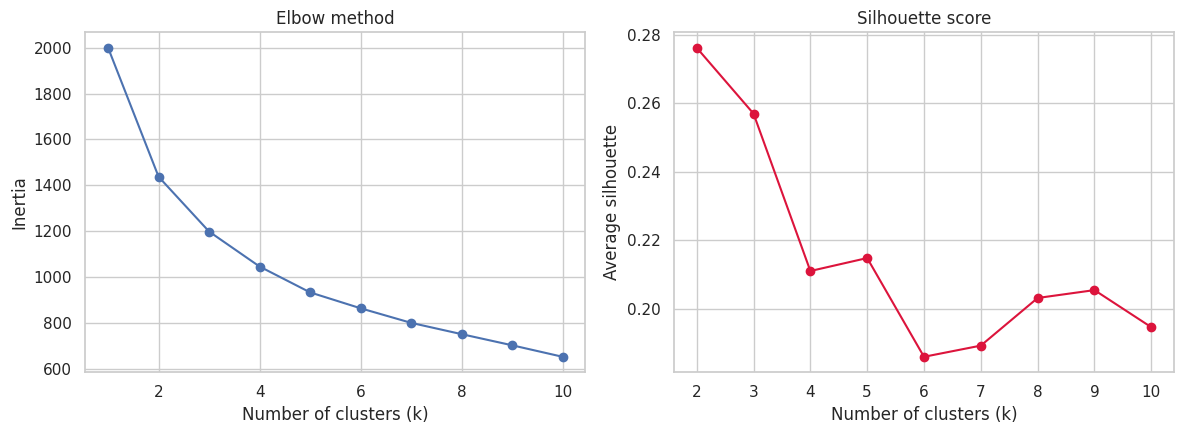

silhouette: {2: 0.276, 3: 0.257, 4: 0.211, 5: 0.215, 6: 0.186, 7: 0.189, 8: 0.203, 9: 0.205, 10: 0.195}


In [10]:
SEED = 42
ks = range(1, 11)
inertia = []
silhouette = {}

for k in ks:
    model = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(X)
    inertia.append(model.inertia_)
    if k > 1:
        silhouette[k] = silhouette_score(X, model.labels_)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(list(ks), inertia, marker="o")
axes[0].set_title("Elbow method")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")
axes[1].plot(list(silhouette), list(silhouette.values()), marker="o", color="crimson")
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Average silhouette")
plt.tight_layout()
plt.show()

print("silhouette:", {k: round(v, 3) for k, v in silhouette.items()})

The inertia falls fast until k = 3 and then more slowly. The silhouette is best at k = 2 (0.276) and k = 3 (0.257), then it drops (0.211 at k = 4). k = 2 seemed too coarse to say much, so I went with **k = 3**.

### Final model

In [11]:
K = 3
km = KMeans(n_clusters=K, n_init=10, random_state=SEED).fit(X)
stocks["cluster"] = km.labels_

# K-Means numbers the clusters randomly. I renumber them from the calmest (0)
# to the most volatile (2) so the numbers keep the same meaning
order = stocks.groupby("cluster")["volatility"].mean().sort_values().index
stocks["cluster"] = stocks["cluster"].map({old: new for new, old in enumerate(order)})

print("silhouette:", round(silhouette_score(X, stocks["cluster"]), 3))
stocks["cluster"].value_counts().sort_index()

silhouette: 0.257


cluster
0    265
1    161
2     74
Name: count, dtype: int64

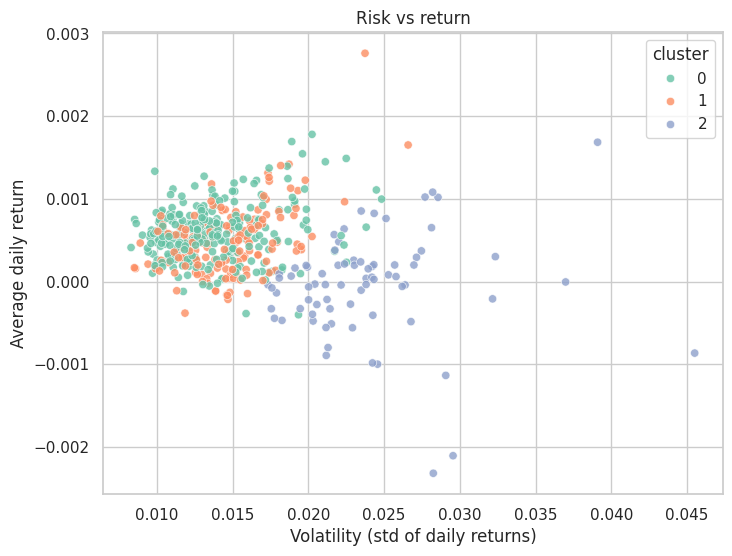

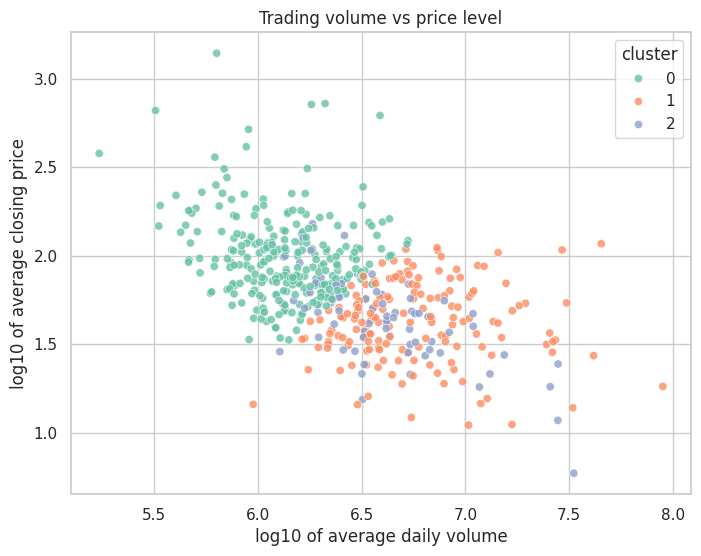

In [12]:
colors = sns.color_palette("Set2", K)

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=stocks, x="volatility", y="avg_daily_return", hue="cluster",
                palette=colors, alpha=0.8, ax=ax)
ax.set_title("Risk vs return")
ax.set_xlabel("Volatility (std of daily returns)")
ax.set_ylabel("Average daily return")
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=stocks, x="log_volume", y="log_price", hue="cluster",
                palette=colors, alpha=0.8, ax=ax)
ax.set_title("Trading volume vs price level")
ax.set_xlabel("log10 of average daily volume")
ax.set_ylabel("log10 of average closing price")
plt.show()

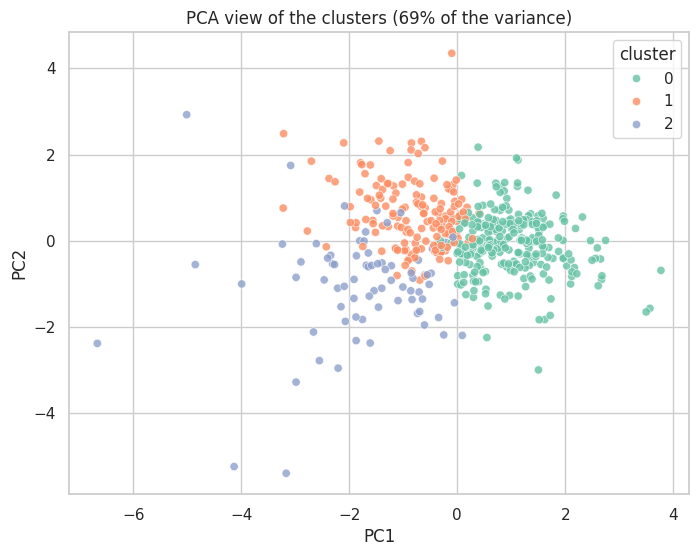

In [13]:
# the 4 features squeezed into 2 axes, to see the clusters in one picture
pca = PCA(n_components=2, random_state=SEED)
pcs = pca.fit_transform(X)

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(x=pcs[:, 0], y=pcs[:, 1], hue=stocks["cluster"], palette=colors, alpha=0.8, ax=ax)
ax.set_title(f"PCA view of the clusters ({pca.explained_variance_ratio_.sum():.0%} of the variance)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.show()

In [14]:
summary = stocks.groupby("cluster").agg(
    n_stocks=("avg_price", "size"),
    avg_daily_return_pct=("avg_daily_return", lambda s: s.mean() * 100),
    volatility_pct=("volatility", lambda s: s.mean() * 100),
    avg_volume_millions=("avg_volume", lambda s: s.mean() / 1e6),
    avg_price_usd=("avg_price", "mean"),
).round(3)
display(summary)

# tickers closest to each cluster centre, as examples
stocks["distance_to_centre"] = np.linalg.norm(X - km.cluster_centers_[km.labels_], axis=1)
for c in range(K):
    examples = stocks[stocks["cluster"] == c].nsmallest(8, "distance_to_centre").index
    print(f"cluster {c}: {', '.join(examples)}")

,n_stocks,avg_daily_return_pct,volatility_pct,avg_volume_millions,avg_price_usd
cluster,,,,,
0,265,0.059,1.375,1.591,119.588
1,161,0.047,1.459,8.014,47.336
2,74,-0.004,2.381,5.595,49.940


cluster 0: WYN, COL, TAP, NTRS, SBAC, CME, PH, EL
cluster 1: BK, EXC, ABT, BBT, CCL, NKE, ICE, CTSH
cluster 2: KORS, STX, CF, NWL, DVN, OKE, KSS, UAA


### What the clusters look like

- **Cluster 0** (265 stocks): expensive and quiet. Average price around 120 USD, low volume (1.6M shares a day), the lowest volatility (1.38%) and the best average return (0.059% a day).
- **Cluster 1** (161 stocks): heavily traded, cheaper stocks (around 47 USD, 8.0M shares a day) with low volatility (1.46%).
- **Cluster 2** (74 stocks): the risky group. The most volatile (2.38%) and a slightly negative average return, with a mix of energy or commodity companies (DVN, OKE, CF) and retail or clothing brands (KSS, KORS, UAA).

### Limits

The silhouette of 0.26 is not high. The clusters overlap a lot in the charts, so they are tendencies and not clear borders, and the differences in average return are small compared to the daily noise. The prices are also not adjusted for splits and spin-offs, so a few stocks (DISCA, DISCK, EBAY, NI, BAX) show one-day drops of 40 to 60% that come from corporate events. That makes their volatility look bigger than it is. Finally, price level is a bit of an arbitrary feature since it depends on how many times a company split its shares.

This is a school exercise on past data, not investment advice.